In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
DATA_PATH = Path("../data/heart_disease_dataset.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Dataset loaded successfully!
Rows: 400
Columns: 14


,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease
0,58,1,1,134,246,0,0,155,0,0.4,1,1,2,1
1,52,0,2,112,245,0,0,143,1,0.1,0,0,3,1
2,59,0,2,126,196,0,0,162,1,1.1,1,0,1,1
3,67,1,1,165,201,0,0,180,0,0.4,2,0,2,0
4,51,1,0,146,174,1,1,133,1,0.9,1,1,2,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      400 non-null    int64  
 1   sex                      400 non-null    int64  
 2   chest_pain_type          400 non-null    int64  
 3   resting_blood_pressure   400 non-null    int64  
 4   cholesterol              400 non-null    int64  
 5   fasting_blood_sugar      400 non-null    int64  
 6   resting_ecg              400 non-null    int64  
 7   max_heart_rate           400 non-null    int64  
 8   exercise_induced_angina  400 non-null    int64  
 9   st_depression            400 non-null    float64
 10  st_slope                 400 non-null    int64  
 11  num_major_vessels        400 non-null    int64  
 12  thalassemia              400 non-null    int64  
 13  heart_disease            400 non-null    int64  
dtypes: float64(1), int64(13)
memory usage

In [6]:
df.describe()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,53.667500,0.662500,1.712500,123.630000,216.627500,0.140000,0.530000,146.717500,0.29250,0.753250,1.177500,0.677500,1.925000,0.555000
std,8.508403,0.473449,1.035628,16.567114,41.379941,0.347422,0.533678,21.104293,0.45548,0.772841,0.645784,0.889084,0.689611,0.497588
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,91.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,1.000000,112.000000,188.000000,0.000000,0.000000,132.000000,0.00000,0.200000,1.000000,0.000000,2.000000,0.000000
50%,54.000000,1.000000,2.000000,124.000000,216.000000,0.000000,1.000000,146.000000,0.00000,0.600000,1.000000,0.000000,2.000000,1.000000
75%,59.000000,1.000000,3.000000,135.000000,246.000000,0.000000,1.000000,161.000000,1.00000,0.900000,2.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,174.000000,336.000000,1.000000,2.000000,202.000000,1.00000,4.900000,2.000000,3.000000,3.000000,1.000000


In [7]:
df.columns.tolist()

['age',
 'sex',
 'chest_pain_type',
 'resting_blood_pressure',
 'cholesterol',
 'fasting_blood_sugar',
 'resting_ecg',
 'max_heart_rate',
 'exercise_induced_angina',
 'st_depression',
 'st_slope',
 'num_major_vessels',
 'thalassemia',
 'heart_disease']

In [8]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
age                        0
sex                        0
chest_pain_type            0
resting_blood_pressure     0
cholesterol                0
fasting_blood_sugar        0
resting_ecg                0
max_heart_rate             0
exercise_induced_angina    0
st_depression              0
st_slope                   0
num_major_vessels          0
thalassemia                0
heart_disease              0
dtype: int64

Total missing values: 0


heart_disease
1    222
0    178
Name: count, dtype: int64
heart_disease
1    55.5
0    44.5
Name: proportion, dtype: float64


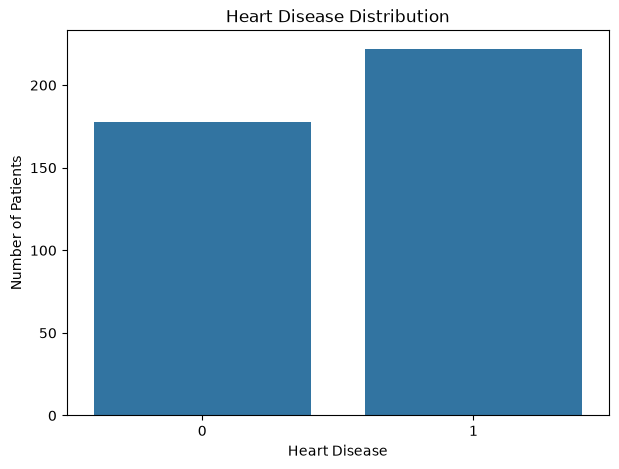

In [9]:
target_counts = df["heart_disease"].value_counts()

print(target_counts)

target_percentage = (
    df["heart_disease"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(target_percentage)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="heart_disease"
)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.show()

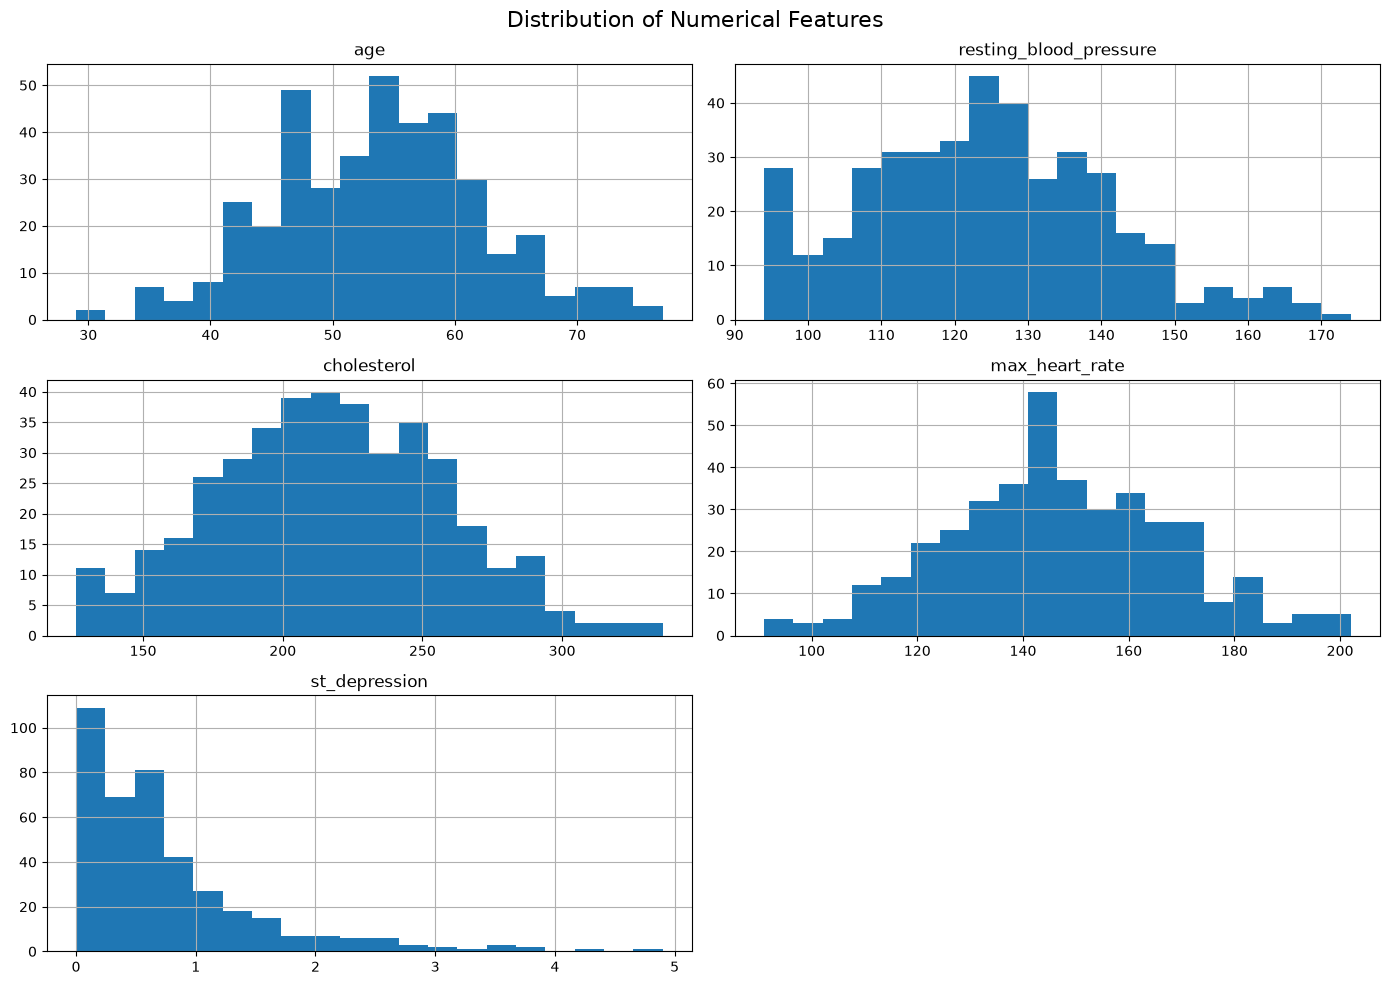

In [10]:
numerical_features = [
    "age",
    "resting_blood_pressure",
    "cholesterol",
    "max_heart_rate",
    "st_depression"
]

df[numerical_features].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

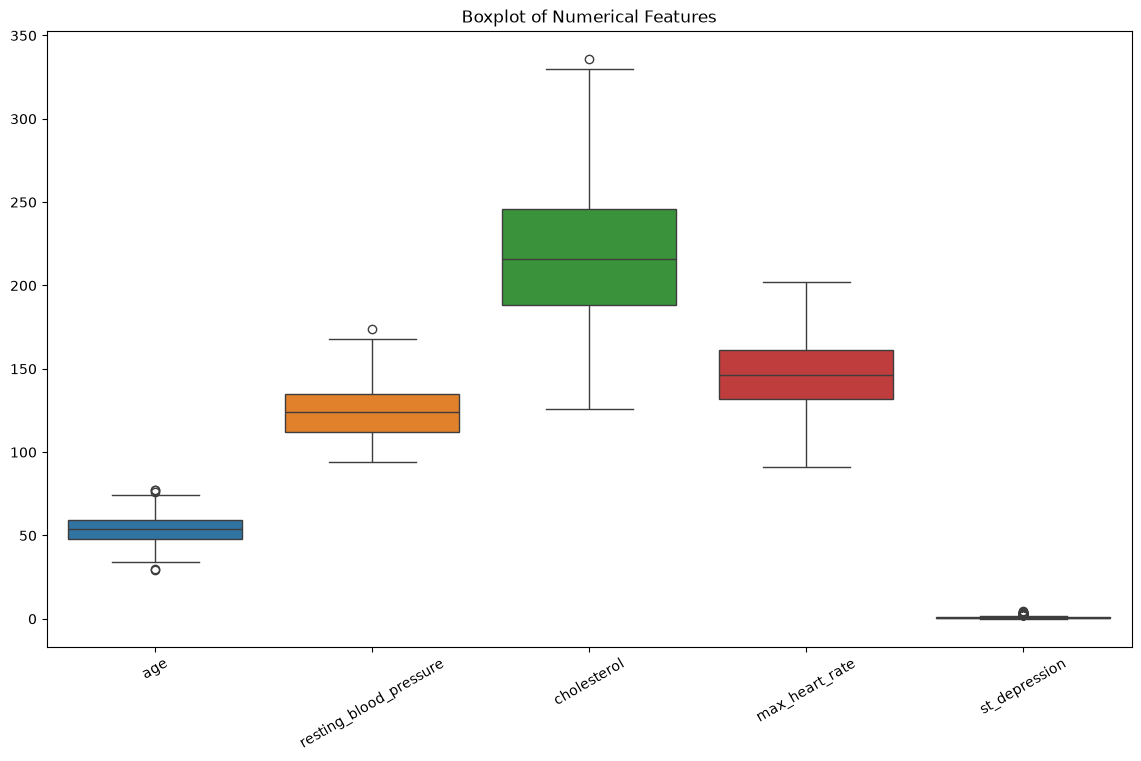

In [11]:
plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df[numerical_features]
)

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=30)

plt.show()

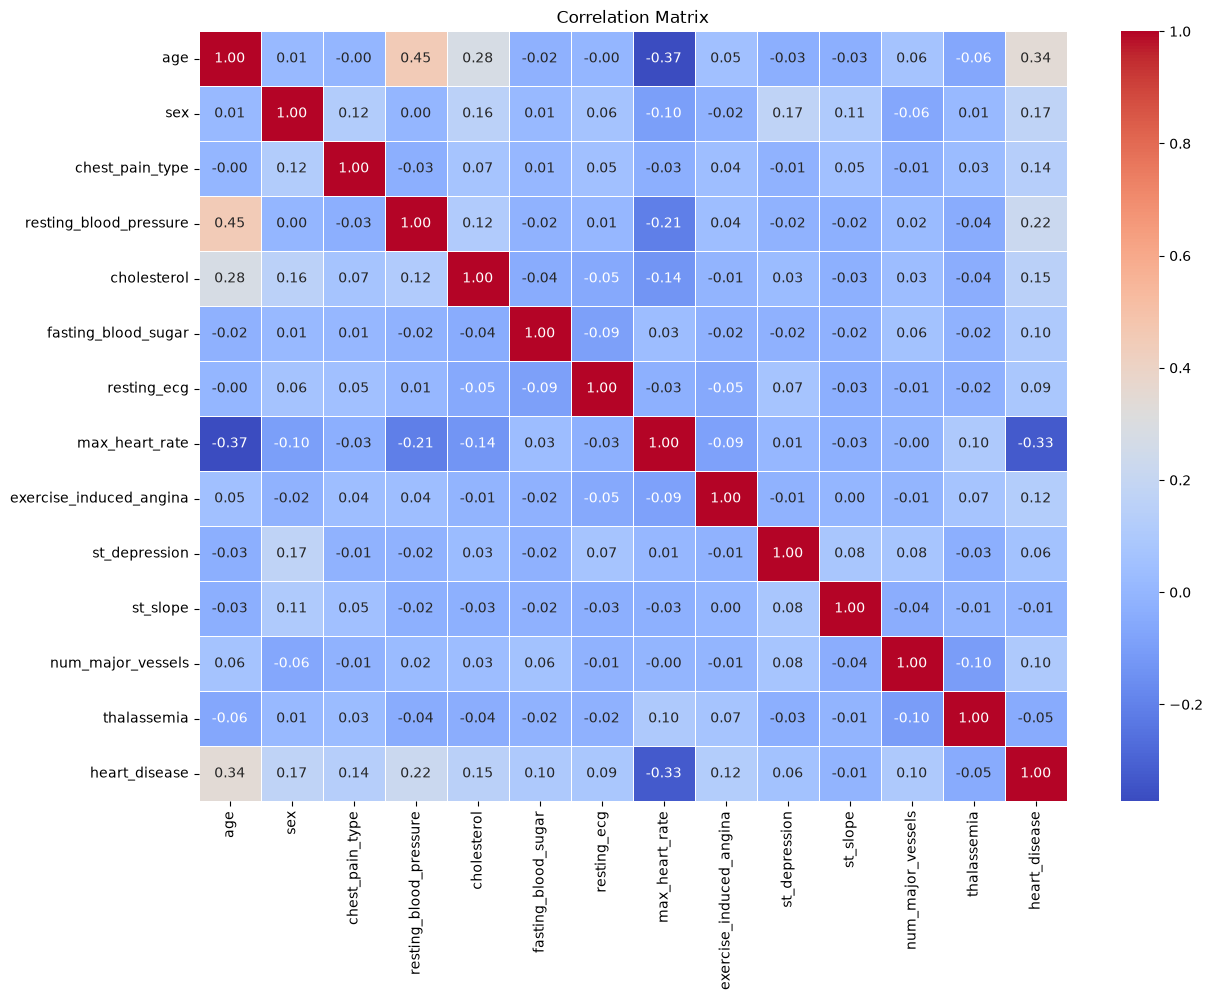

In [12]:
correlation_matrix = df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

In [13]:
target_correlation = (
    df.corr()["heart_disease"]
    .sort_values(ascending=False)
)

print(target_correlation)

heart_disease              1.000000
age                        0.341464
resting_blood_pressure     0.217725
sex                        0.169419
cholesterol                0.147854
chest_pain_type            0.135328
exercise_induced_angina    0.122360
fasting_blood_sugar        0.100324
num_major_vessels          0.099679
resting_ecg                0.088150
st_depression              0.061122
st_slope                  -0.010958
thalassemia               -0.046380
max_heart_rate            -0.327515
Name: heart_disease, dtype: float64


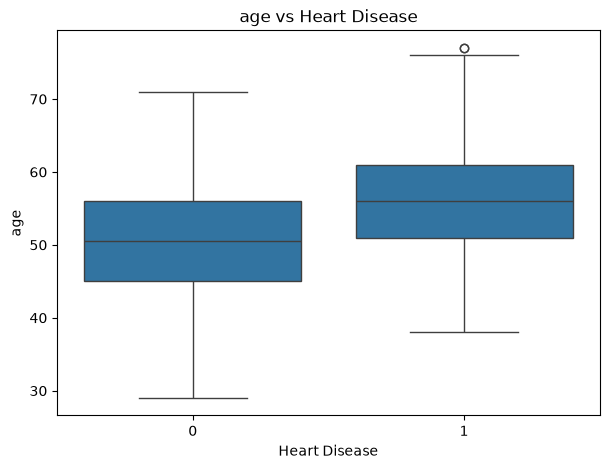

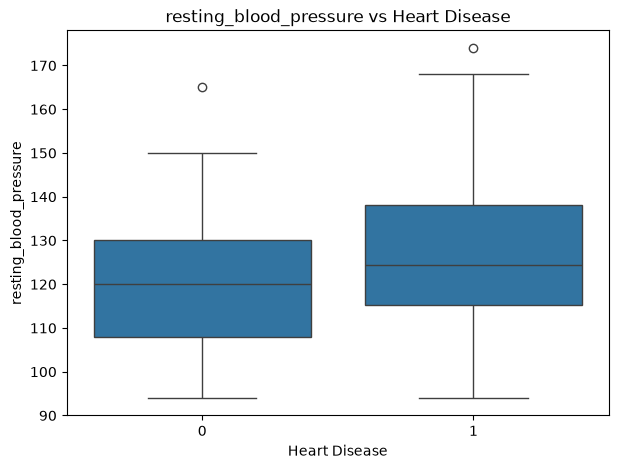

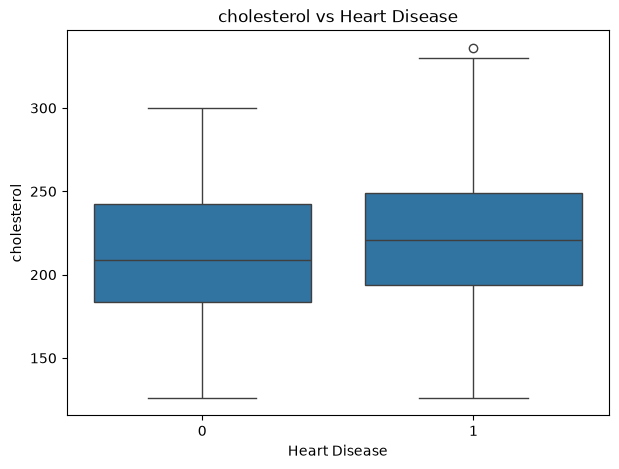

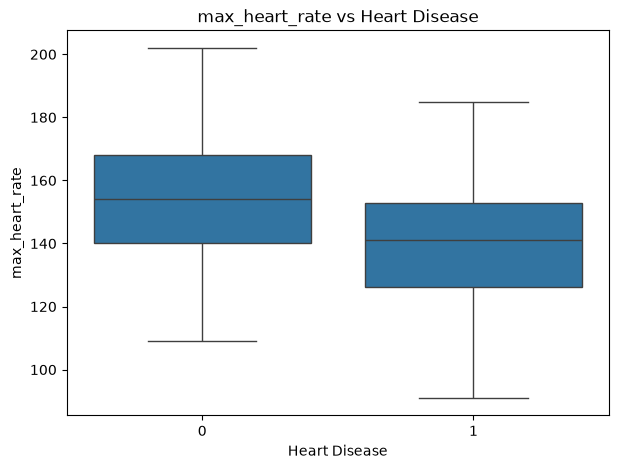

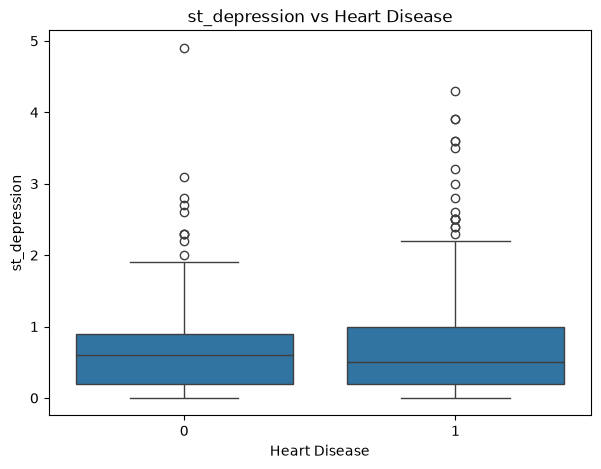

In [14]:
for feature in numerical_features:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="heart_disease",
        y=feature
    )

    plt.title(
        f"{feature} vs Heart Disease"
    )

    plt.xlabel("Heart Disease")
    plt.ylabel(feature)

    plt.show()

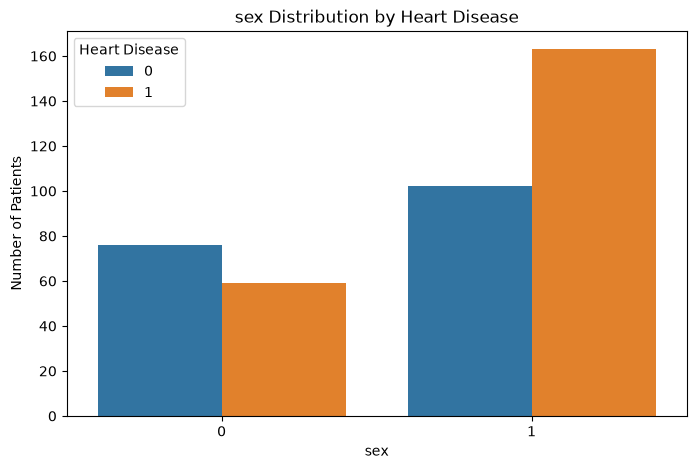

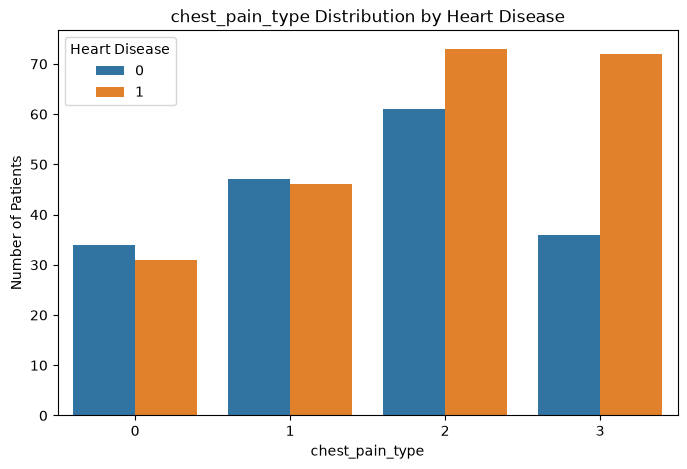

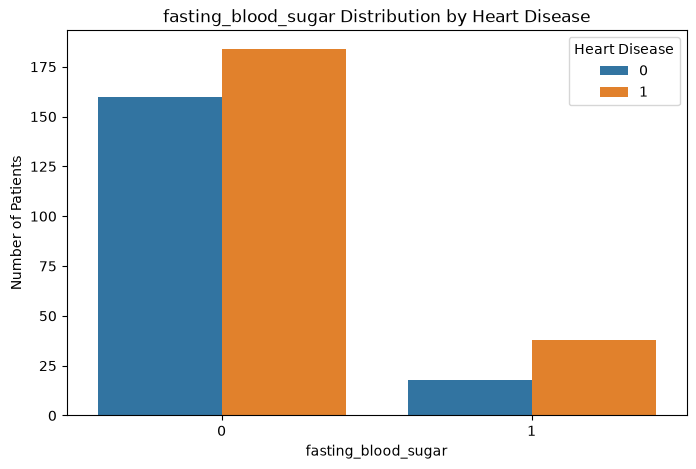

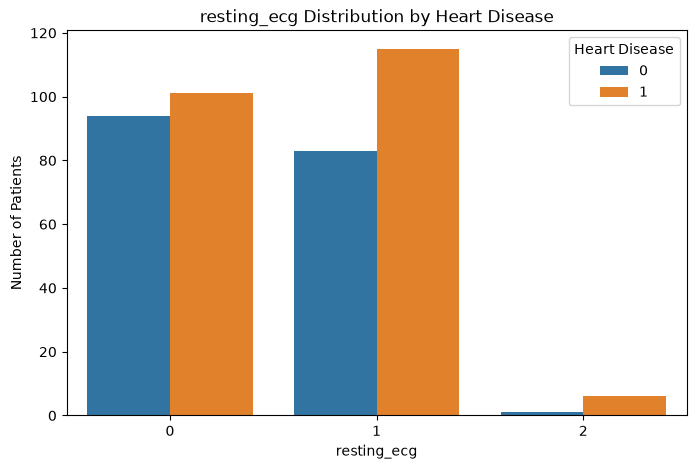

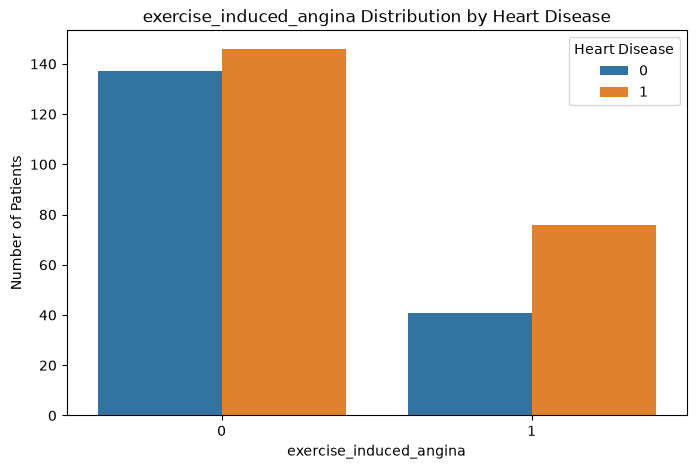

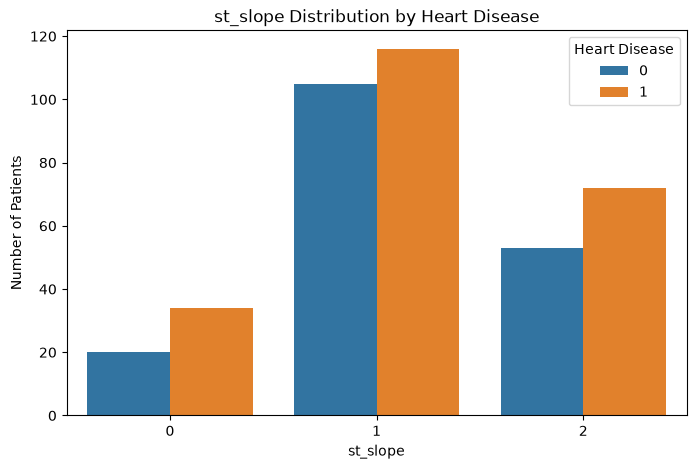

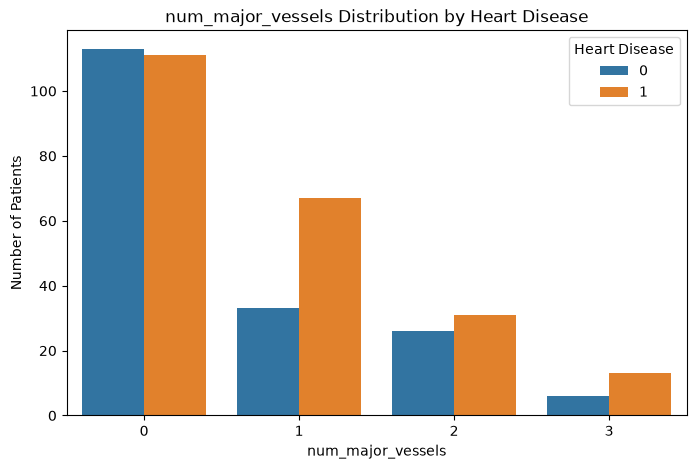

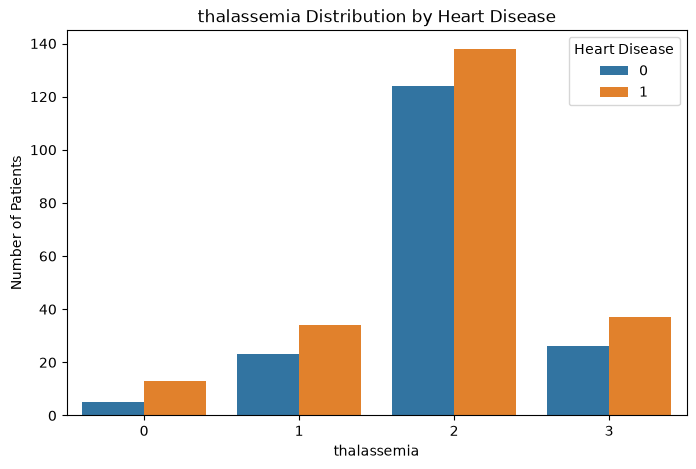

In [15]:
categorical_features = [
    "sex",
    "chest_pain_type",
    "fasting_blood_sugar",
    "resting_ecg",
    "exercise_induced_angina",
    "st_slope",
    "num_major_vessels",
    "thalassemia"
]

for feature in categorical_features:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=feature,
        hue="heart_disease"
    )

    plt.title(
        f"{feature} Distribution by Heart Disease"
    )

    plt.xlabel(feature)
    plt.ylabel("Number of Patients")

    plt.legend(
        title="Heart Disease"
    )

    plt.show()

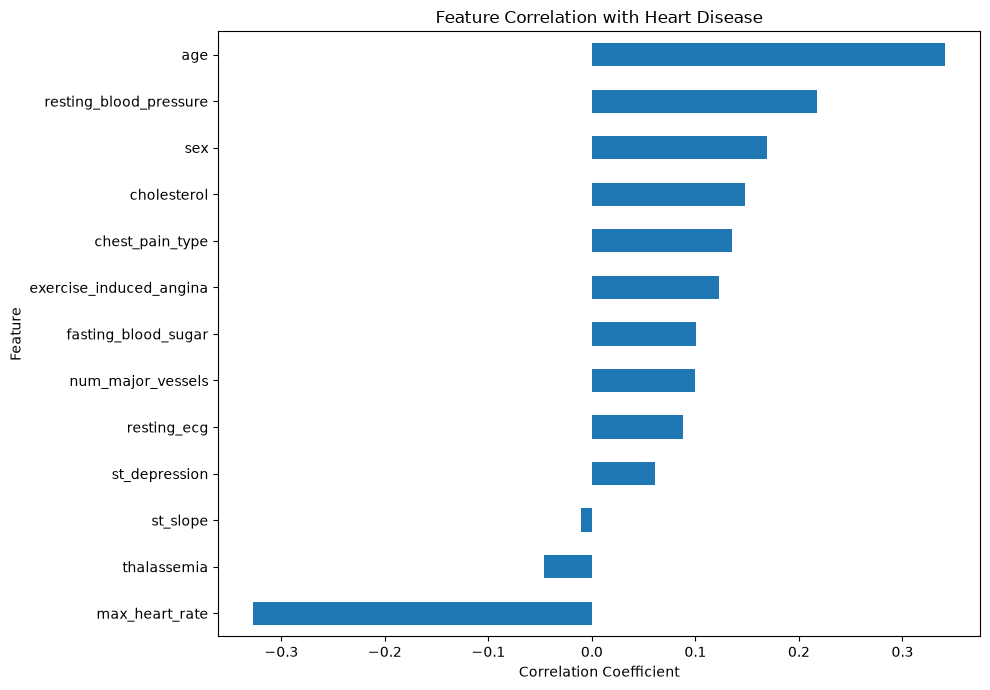

In [16]:
target_corr = (
    df.corr()["heart_disease"]
    .drop("heart_disease")
    .sort_values()
)

plt.figure(figsize=(10, 7))

target_corr.plot(
    kind="barh"
)

plt.title("Feature Correlation with Heart Disease")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC



In [18]:
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.calibration import CalibratedClassifierCV

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "SVM": CalibratedClassifierCV(
        SVC(random_state=42),
        ensemble=False
    )
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)


Logistic Regression
[[22 14]
 [12 32]]


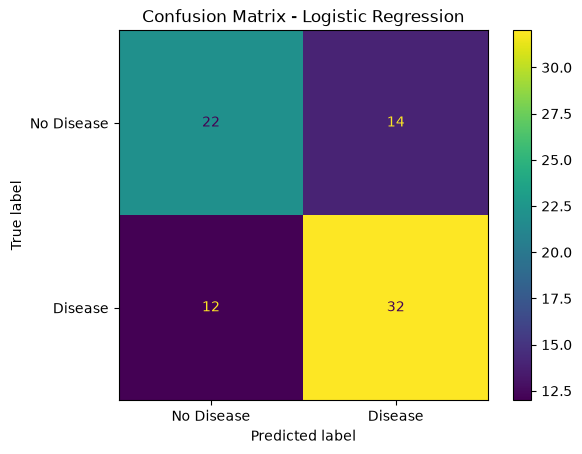


Decision Tree
[[16 20]
 [14 30]]


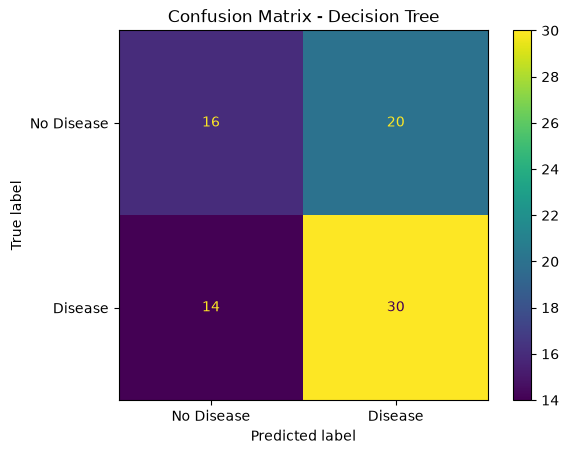


Random Forest
[[22 14]
 [10 34]]


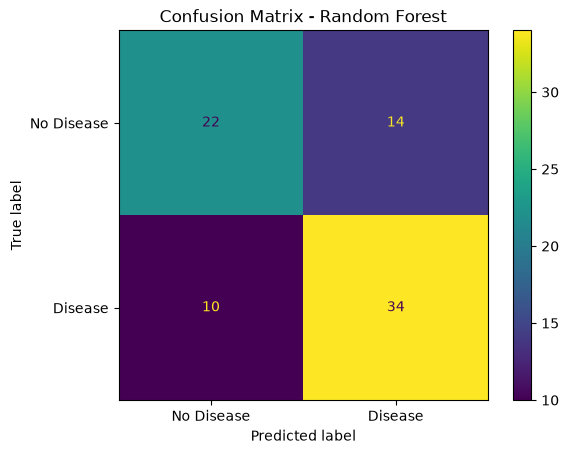


SVM
[[21 15]
 [13 31]]


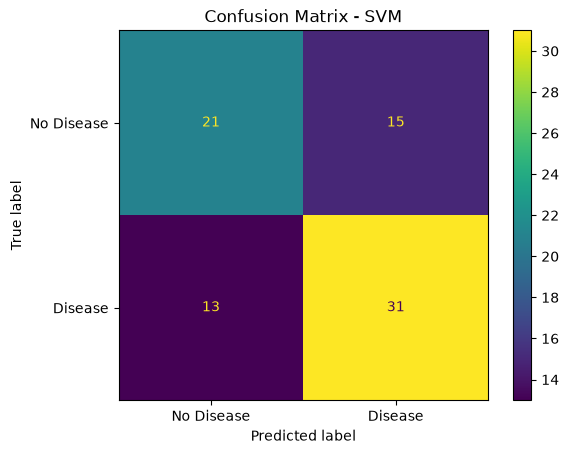

In [20]:
for name, model in models.items():

    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print(f"\n{name}")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Disease", "Disease"]
    )

    disp.plot()

    plt.title(
        f"Confusion Matrix - {name}"
    )

    plt.show()

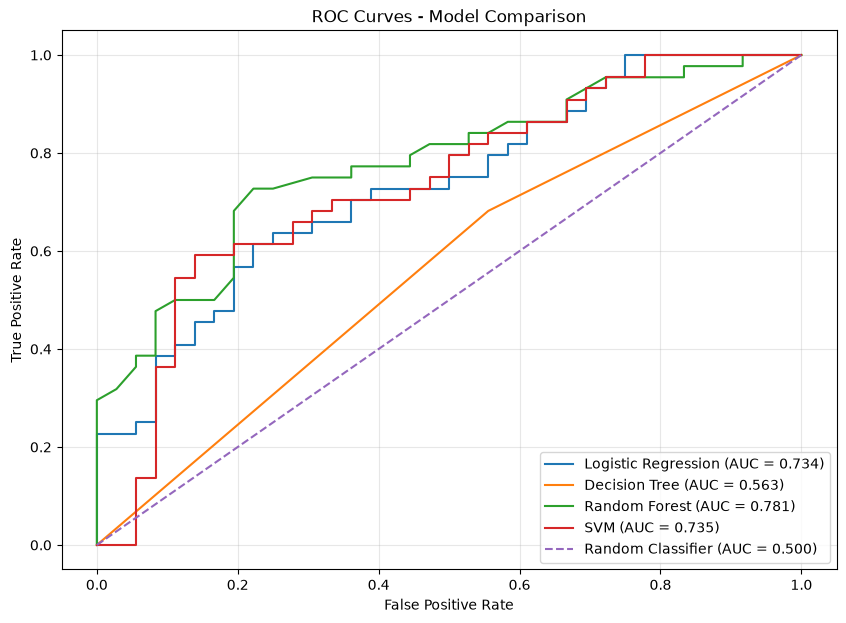

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 7))

for name, model in models.items():

    # Get probability of the positive class
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # Calculate AUC
    auc_score = roc_auc_score(y_test, y_prob)

    # Plot ROC curve
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier (AUC = 0.500)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

In [23]:
rf_model = models["Random Forest"]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
7,max_heart_rate,0.175388
0,age,0.146664
4,cholesterol,0.140299
3,resting_blood_pressure,0.131372
9,st_depression,0.104426
2,chest_pain_type,0.057524
11,num_major_vessels,0.048840
1,sex,0.044671
10,st_slope,0.037854
12,thalassemia,0.035447


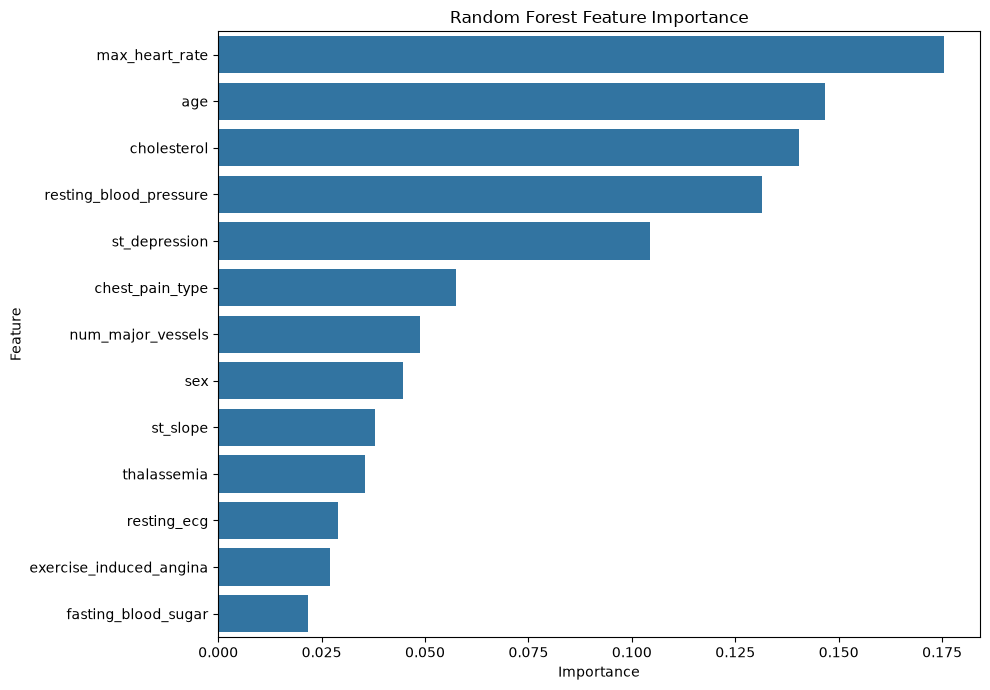

In [24]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

results = []

for name, model in models.items():

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    specificity = tn / (tn + fp)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Specificity": specificity
    })

final_results = pd.DataFrame(results)

final_results = final_results.sort_values(
    by="F1-Score",
    ascending=False
)

final_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Specificity
2,Random Forest,0.7000,0.708333,0.772727,0.739130,0.780934,0.611111
0,Logistic Regression,0.6750,0.695652,0.727273,0.711111,0.734217,0.611111
3,SVM,0.6375,0.659574,0.704545,0.681319,0.735480,0.555556
1,Decision Tree,0.5750,0.600000,0.681818,0.638298,0.563131,0.444444


In [26]:
final_results.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [ ]:
display_results = final_results.copy()

percentage_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "Specificity"
]

for column in percentage_columns:
    display_results[column] = (
        display_results[column] * 100
    ).round(2)

display_results["ROC-AUC"] = display_results["ROC-AUC"].round(4)

display_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Specificity
2,Random Forest,70.00,70.83,77.27,73.91,0.7809,61.11
0,Logistic Regression,67.50,69.57,72.73,71.11,0.7342,61.11
3,SVM,63.75,65.96,70.45,68.13,0.7355,55.56
1,Decision Tree,57.50,60.00,68.18,63.83,0.5631,44.44


: 